In [1]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Run scan_L_A.py to generate the results for Fig2.ipynb


In [3]:
# Set global matplotlib formatting for ICLR paper compatibility
# Set global font to Times New Roman

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
})

import seaborn as sns
sns.set_context("paper")
sns.set_style(None)


In [4]:
cwd = os.getcwd()
file1 = './results/sweep_L_A/data_max_move_1_L_9.pkl'
file2 = './results/sweep_L_A/data_max_move_15_L_9.pkl'
data_dict_l = [pkl.load(open(file1, 'rb')), pkl.load(open(file2, 'rb'))]

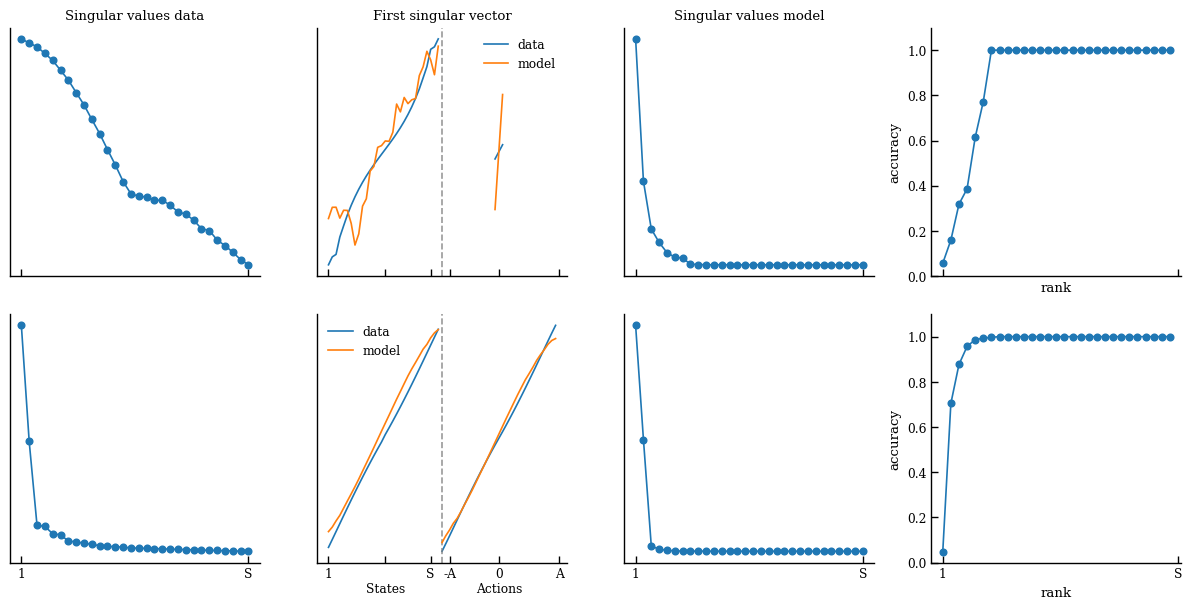

In [26]:
fig, axs_l = plt.subplots(2, 4, figsize=(4*3, 6), sharex='col')
large_A = 15

axs_l[0, 0].set_title('Singular values data')
axs_l[0, 1].set_title('First singular vector')
axs_l[0, 2].set_title('Singular values model')
for data_dict, axs in zip(data_dict_l, axs_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    W /= np.linalg.norm(W)
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    rank = 1
    axs[0].plot(S, marker='o')
    axs[0].set_yticks([])

    L = data_dict['C'].length_corridors[0]
    A = data_dict['C'].max_move
    axs[1].plot(np.arange(L), V[:rank, :L].T, label='data', c='tab:blue')
    axs[1].plot(np.arange(L+large_A-A, L+large_A-A+2*A+1), V[:rank, L:].T, c='tab:blue')
    axs[1].axvline(L, color='gray', linestyle='--', alpha=0.8)
    U, S, V = np.linalg.svd(W, full_matrices=False)
    axs[1].plot(np.arange(L), U[:L, :rank], label='model', c='tab:orange')
    axs[1].plot(np.arange(L+large_A-A, L+large_A-A+2*A+1), U[L:, :rank], c='tab:orange')
    axs[1].legend()
    axs[1].set_yticks([])
    
    axs[2].plot(S, marker='o')
    axs[2].set_yticks([])
    plt.tight_layout()

    accuracy_l = []
    for rank in range(1, W.shape[1]):
        W_rec = U[:, :rank]@np.diag(S[:rank])@V[:rank]
        accuracy_l.append(calc_accuracy_from_W(W_rec, X, y))
    axs[-1].plot(accuracy_l, marker='o')
    axs[-1].set_ylabel('accuracy')
    axs[-1].set_xlabel('rank')
    axs[-1].set_ylim(0, 1.1)
 
axs[0].set_xticks([0, L-1])
axs[0].set_xticklabels(['1', 'S'])

axs[1].set_xticks([0, L/2, L-3, L+2, L+A, L+2*A+1])
axs[1].set_xticklabels(['1', '\nStates', 'S', '-A', '0\nActions', 'A'])
 
axs[2].set_xticks([0, L-1])
axs[2].set_xticklabels(['1', 'S'])

axs[3].set_xticks([0, L-1])
axs[3].set_xticklabels(['1', 'S'])

os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./final_results/figures/fig3.png', dpi=300)
plt.show()


In [6]:
data_dict['accuracy_l'][-1]

1.0